 O algoritmo de Leiden é uma técnica altamente eficiente de detecção de comunidades e agrupamento em grafos e redes complexas. Desenvolvido como uma evolução do famoso método de Louvain, ele supera seu antecessor ao garantir comunidades mais coesas e internamente bem conectadas, além de ser muito mais rápido em redes massivas.

In [98]:
import igraph as ig
import leidenalg
import networkx as nx
import matplotlib.pyplot as plt
import community as community_louvain
import numpy as np
import scipy

O algoritmo de Louvain funciona através de uma otimização heurística e gulosa da modularidade (uma métrica que mede quão densamente conectados estão os nós dentro de uma comunidade em relação ao resto da rede). Ele opera em duas fases que se repetem iterativamente:

1. Fase de Atribuição (Otimização Local): Inicialmente, cada nó é a sua própria comunidade. O algoritmo avalia todos os vizinhos de um nó e move-o para a comunidade do vizinho que resultar no maior aumento imediato da modularidade global do grafo. Esta etapa repete-se até que nenhum nó possa ser movido com ganho positivo de modularidade.

2. Fase de Agregação (Construção do Supergrafo): Uma vez que a primeira fase estabiliza, todas as comunidades recém-formadas colapsam e transformam-se em "supernós". As arestas entre os nós da mesma comunidade tornam-se o "peso interno" do supernó, e as arestas entre comunidades diferentes são somadas para formar as novas conexões entre os supernós.

3. Repetição Hierárquica: O algoritmo repete as Fases 1 e 2 no novo grafo comprimido (de supernós). Cada iteração forma um nível na hierarquia, fundindo comunidades cada vez maiores.

4. Convergência: O processo termina quando a fase de agregação resulta num grafo onde a tentativa de mover qualquer supernó não aumenta mais a modularidade. O resultado final é a estrutura de comunidades com o valor máximo de modularidade que a heurística conseguiu alcançar.

O algoritmo de Leiden é uma evolução direta do Louvain, desenhado exatamente para consertar a sua maior falha: a tendência de criar comunidades "monstro" ou internamente desconexas (o chamado limite de resolução). Ele funciona adicionando uma etapa extra e brilhante ao processo:

1. Fase de Atribuição Local: Tal como o Louvain, começa de forma gulosa, movendo nós individualmente para as comunidades vizinhas que mais aumentam a modularidade.

2. A Grande Diferença (Fase de Refinamento): Em vez de colapsar imediatamente essas novas comunidades num supernó definitivo, o Leiden "dá um passo atrás". Ele cria partições menores e aleatórias dentro da comunidade recém-formada, permitindo que os nós se reorganizem para garantir que estão realmente bem conectados entre si.

3. Agregação Segura: A agregação para construir o novo nível do grafo (supernós) é feita com base nesses subgrupos refinados, e não na partição gigante inicial. Isso impede que nós mal conectados sejam cimentados juntos para sempre.

4. Repetição Hierárquica: O processo repete-se iterativamente nos níveis superiores, fundindo os supernós aos poucos.

5. Garantia Matemática: O Leiden repete este ciclo até à convergência, com uma prova matemática rigorosa de que, no final, todas as comunidades geradas serão internamente conectadas (o Louvain falha nisto, criando frequentemente comunidades onde o lado A não tem nenhuma aresta direta com o lado B).

Comunidades encontradas:
Cluster 0: [4, 5, 6, 7]
Cluster 1: [0, 1, 2, 3]


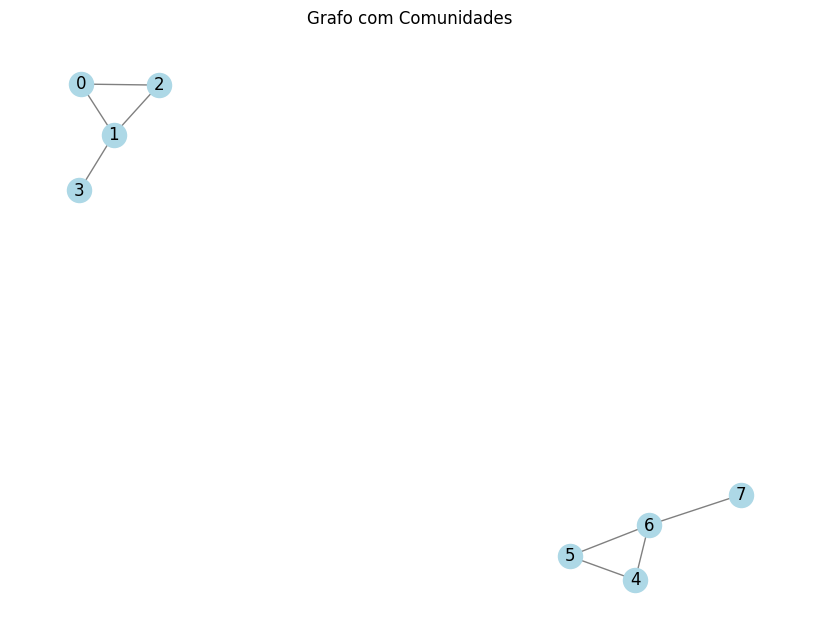

Modularidade: 0.5000


In [99]:
#
# Aqui sou eu testando o leiden, usei llm nesse exemplo 
#
edges = [(0,1), (0,2), (1,2), (1,3), 
         (4,5), (4,6), (5,6), (6,7)]
G = ig.Graph(edges, directed=False)


partition = leidenalg.find_partition(G, leidenalg.ModularityVertexPartition)


print("Comunidades encontradas:")
for i, community in enumerate(partition):
    print(f"Cluster {i}: {community}")

plt.figure(figsize=(8, 6))
nx_G = nx.Graph(edges)
pos = nx.spring_layout(nx_G)
nx.draw(nx_G, pos, with_labels=True, node_color='lightblue', edge_color='gray')
plt.title("Grafo com Comunidades")
plt.show()


print(f"Modularidade: {partition.quality():.4f}")


### Dataset Benchmark: Aplicação obrigatória no Dataset Zachary Karate Club para fins de comparação

Comunidades encontradas pelo Louvain:
Comunidade 0: {16, 4, 5, 6, 10}
Comunidade 1: {0, 1, 2, 3, 7, 11, 12, 13, 17, 19, 21}
Comunidade 2: {32, 33, 8, 9, 14, 15, 18, 20, 22, 26, 29, 30}
Comunidade 3: {23, 24, 25, 27, 28, 31}


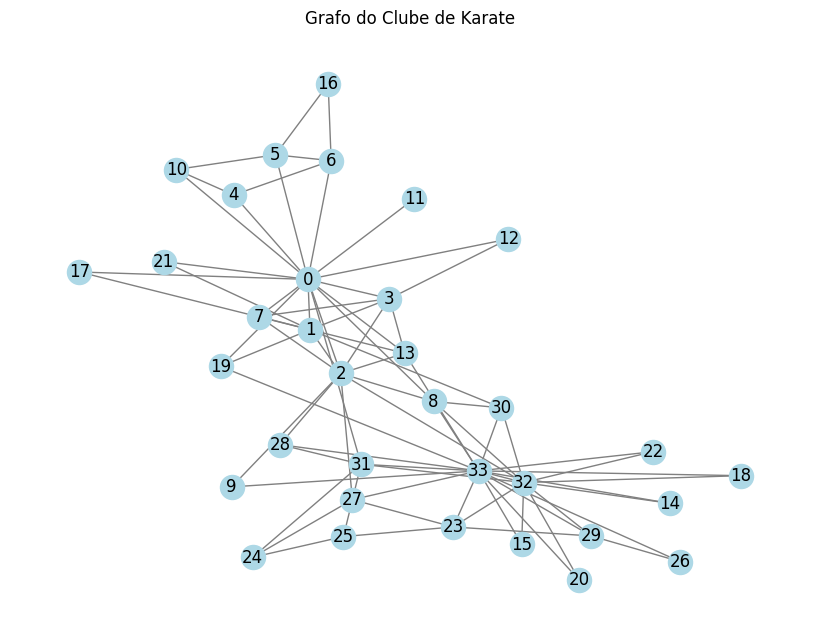

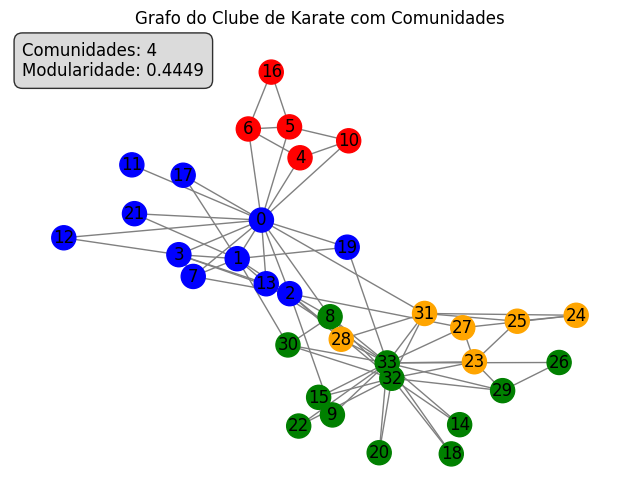

In [100]:



karate_club = nx.karate_club_graph()

comunidades_louvain = nx.community.louvain_communities(karate_club)
print("Comunidades encontradas pelo Louvain:")
for i, comunidade in enumerate(comunidades_louvain):
    print(f"Comunidade {i}: {comunidade}")

qtd_comunidades = len(comunidades_louvain)
modularidade = nx.community.modularity(karate_club, comunidades_louvain)

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(karate_club)
nx.draw(karate_club, pos, with_labels=True, node_color='lightblue', edge_color='gray')
plt.title("Grafo do Clube de Karate")
plt.show()

#pintando as comunidades no grafo do karate

#Comunidades encontradas pelo Louvain:
#Comunidade 0: {0, 4, 5, 6, 10, 11, 16, 17, 19, 21}
#Comunidade 1: {1, 2, 3, 7, 12, 13}
#Comunidade 2: {32, 33, 8, 9, 14, 15, 18, 20, 22, 26, 29, 30}
#Comunidade 3: {23, 24, 25, 27, 28, 31}

# Criando um dicionário para mapear cada nó à sua comunidade
comunidade_dict = {}
for i, comunidade in enumerate(comunidades_louvain):
    for node in comunidade:
        comunidade_dict[node] = i



texto_estatisticas = f"Comunidades: {qtd_comunidades}\nModularidade: {modularidade:.4f}"


cores = ['red', 'blue', 'green', 'orange']
node_colors = [cores[comunidade_dict[node]] for node in karate_club.nodes()]
fig, ax = plt.subplots(figsize=(8, 6))
pos = nx.spring_layout(karate_club, seed=42)
nx.draw(karate_club, pos, with_labels=True, node_color=node_colors, edge_color='gray')

ax.text(0.02, 0.98, texto_estatisticas, 
        transform=ax.transAxes, 
        fontsize=12,
        verticalalignment='top', 
        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgrey', alpha=0.8, edgecolor='black'))

plt.title("Grafo do Clube de Karate com Comunidades")
plt.show()




Comunidades encontradas pelo Leiden:
Cluster 0: [8, 9, 14, 15, 18, 20, 22, 26, 29, 30, 32, 33]
Cluster 1: [0, 1, 2, 3, 7, 11, 12, 13, 17, 19, 21]
Cluster 2: [23, 24, 25, 27, 28, 31]
Cluster 3: [4, 5, 6, 10, 16]
Modularidade do Leiden: 0.4198


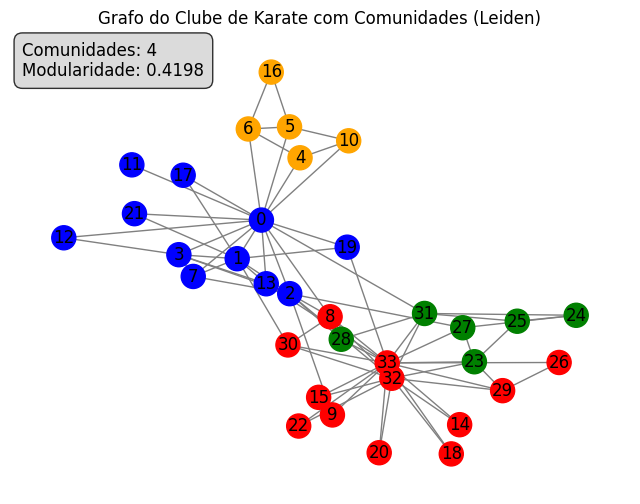

In [101]:
# comparando com leiden

# Convertendo o grafo do karate para igraph
from email.mime import text


karate_ig = ig.Graph.from_networkx(karate_club)
partition_leiden = leidenalg.find_partition(karate_ig, leidenalg.ModularityVertexPartition)
print("Comunidades encontradas pelo Leiden:")
for i, community in enumerate(partition_leiden):
    print(f"Cluster {i}: {community}")

# Criando um dicionário para mapear cada nó à sua comunidade do Leiden
comunidade_leiden_dict = {}
for i, comunidade in enumerate(partition_leiden):
    for node in comunidade:
        comunidade_leiden_dict[node] = i

#valor modularidade do leiden
print(f"Modularidade do Leiden: {partition_leiden.quality():.4f}")
qtd_comunidades_leiden = len(partition_leiden)

texto_estatisticas_2 = f"Comunidades: {qtd_comunidades_leiden}\nModularidade: {partition_leiden.quality():.4f}"

cores_leiden = ['red', 'blue', 'green', 'orange']
node_colors_leiden = [cores_leiden[comunidade_leiden_dict[node]] for node in karate_club.nodes()]
fig, ax = plt.subplots(figsize=(8, 6))

ax.text(0.02, 0.98, texto_estatisticas_2,
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgrey', alpha=0.8, edgecolor='black'))


pos = nx.spring_layout(karate_club, seed=42)
nx.draw(karate_club, pos, with_labels=True, node_color=node_colors_leiden, edge_color='gray')
ax.set_title("Grafo do Clube de Karate com Comunidades (Leiden)")


plt.show()

### Dataset Secundário: Aplicação em um conjunto de dados à escolha do grupo (Les Misérables).

Comunidades encontradas pelo Louvain em Les Miserables:


Cluster 0: {'Cravatte', 'Napoleon', 'Geborand', 'Myriel', 'Champtercier', 'MmeMagloire', 'CountessDeLo', 'Count', 'OldMan', 'MlleBaptistine'}
Cluster 1: {'Zephine', 'Favourite', 'Fameuil', 'Marguerite', 'Tholomyes', 'Blacheville', 'Listolier', 'Dahlia', 'Fantine'}
Cluster 2: {'Brevet', 'Judge', 'Chenildieu', 'Bamatabois', 'Champmathieu', 'Cochepaille'}
Cluster 3: {'Montparnasse', 'Babet', 'Thenardier', 'Eponine', 'Brujon', 'Claquesous', 'MmeThenardier', 'Gueulemer', 'Anzelma', 'Boulatruelle'}
Cluster 4: {'Cosette', 'BaronessT', 'MotherInnocent', 'Valjean', 'Labarre', 'MlleVaubois', 'Isabeau', 'Pontmercy', 'LtGillenormand', 'Gribier', 'Fauchelevent', 'Javert', 'Scaufflaire', 'Simplice', 'Gervais', 'MlleGillenormand', 'Marius', 'Perpetue', 'MmeDeR', 'Woman2', 'MmePontmercy', 'Magnon', 'Toussaint', 'Woman1', 'Gillenormand'}
Cluster 5: {'MmeHucheloup', 'Bahorel', 'Prouvaire', 'Combeferre', 'Child1', 'Feuilly', 'Grantaire', 'Courfeyrac', 'Joly', 'MmeBurgon', 'Enjolras', 'MotherPlutarch', '

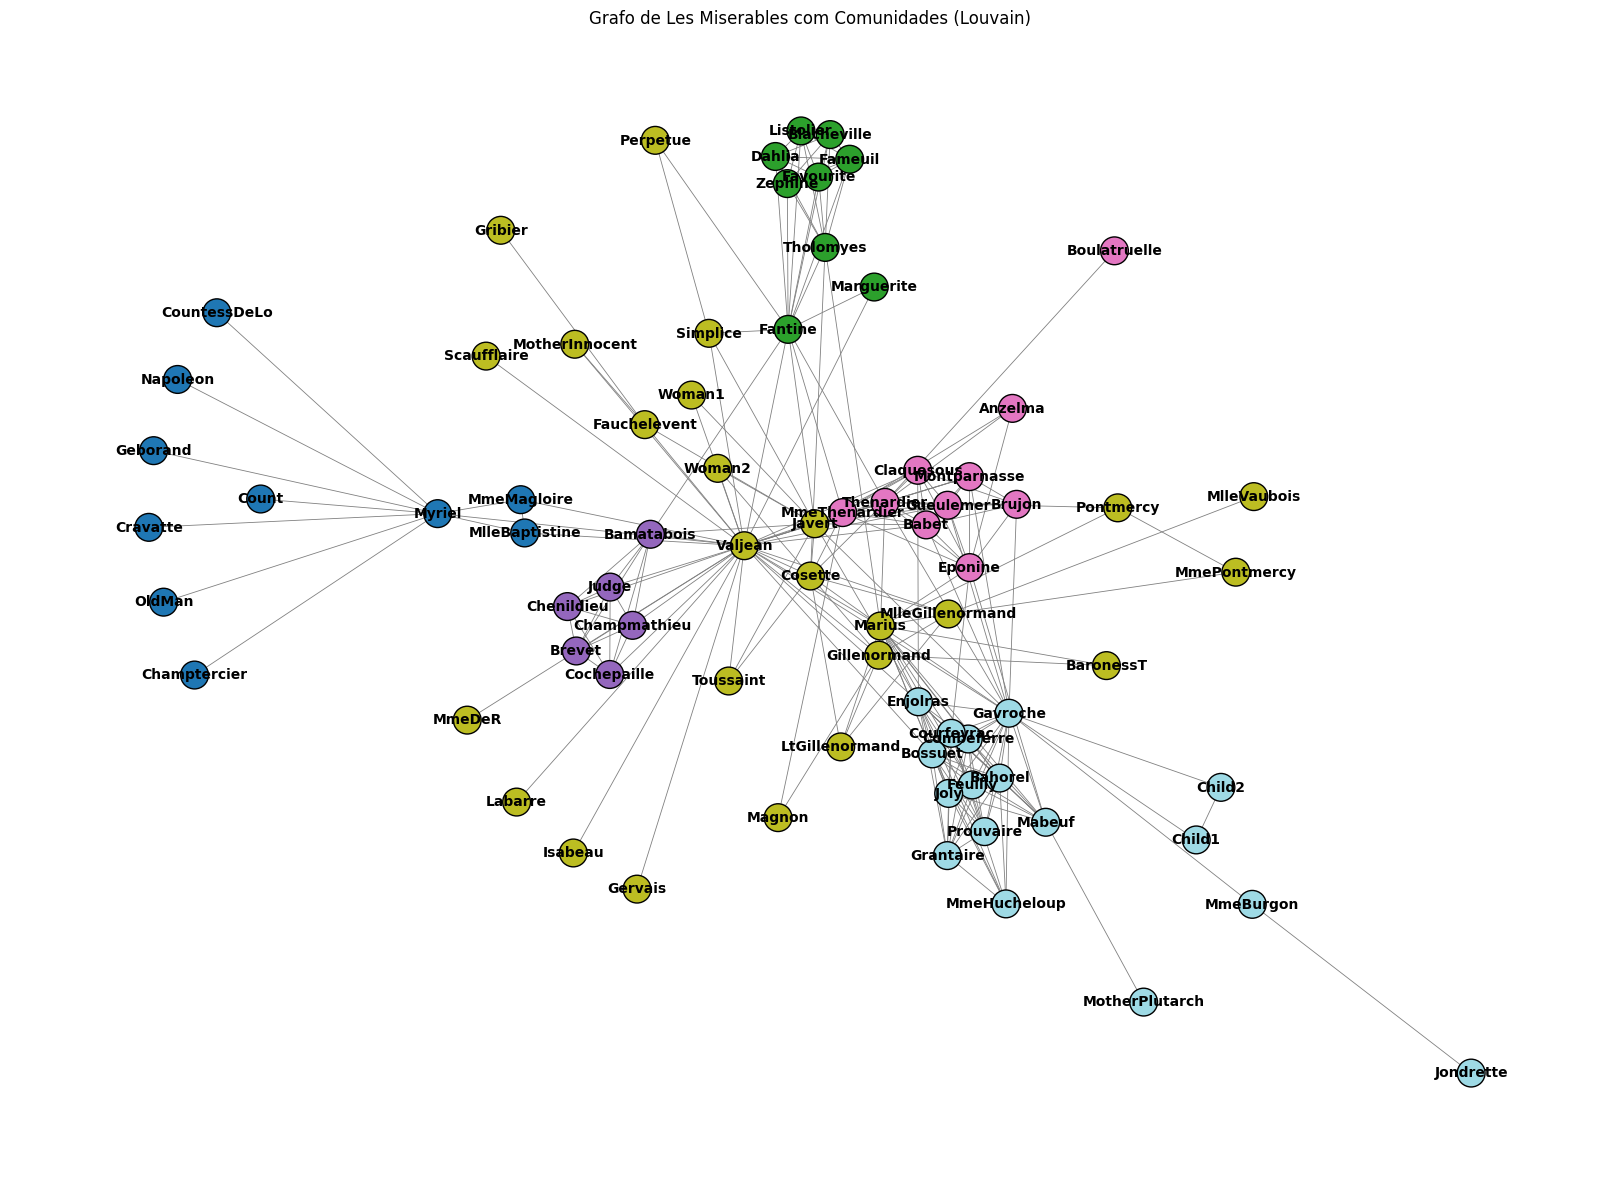

In [102]:
les_miserables = nx.les_miserables_graph()

# aplicando o louvain
comunidades_louvain_les = nx.community.louvain_communities(les_miserables, seed=42)
print("Comunidades encontradas pelo Louvain em Les Miserables:")
for i, comunidade in enumerate(comunidades_louvain_les):
    print(f"Cluster {i}: {comunidade}")

# mapeia cada nó para sua comunidade
comunidade_dict = {}
for i, comunidade in enumerate(comunidades_louvain_les):
    for node in comunidade:
        comunidade_dict[node] = i

# cores por comunidade
num_comunidades = len(comunidades_louvain_les)
colormap = plt.colormaps["tab20"].resampled(num_comunidades)
node_colors = [colormap(comunidade_dict[node]) for node in les_miserables.nodes()]




# layout mais estável e com repulsão melhor ajustada
pos = nx.spring_layout(les_miserables, seed=42, k=0.55, iterations=200, weight="weight")

fig, ax = plt.subplots(figsize=(16, 12))
nx.draw_networkx_edges(les_miserables, pos, ax=ax, edge_color="gray", width=0.6)
nx.draw_networkx_nodes(
    les_miserables,
    pos,
    ax=ax,
    node_color=node_colors,
    node_size=400,
    linewidths=1,
    edgecolors="black",
)

nx.draw_networkx_labels(les_miserables, pos, labels=None, font_size=10, font_weight="bold", ax=ax)

ax.set_title("Grafo de Les Miserables com Comunidades (Louvain)")
ax.set_axis_off()
fig.subplots_adjust(left=0, right=1, top=0.95, bottom=0)
plt.show()




Comunidades encontradas pelo Leiden em Les Miserables:
Cluster: ['MmeBurgon', 'Jondrette', 'Gavroche', 'Mabeuf', 'Enjolras', 'Combeferre', 'Prouvaire', 'Feuilly', 'Courfeyrac', 'Bahorel', 'Bossuet', 'Joly', 'Grantaire', 'MotherPlutarch', 'Child1', 'Child2', 'MmeHucheloup']
Cluster: ['Valjean', 'Labarre', 'MmeDeR', 'Isabeau', 'Gervais', 'Fauchelevent', 'Bamatabois', 'Scaufflaire', 'Woman1', 'Judge', 'Champmathieu', 'Brevet', 'Chenildieu', 'Cochepaille', 'MotherInnocent', 'Gribier']
Cluster: ['Cosette', 'Pontmercy', 'Woman2', 'Gillenormand', 'Magnon', 'MlleGillenormand', 'MmePontmercy', 'MlleVaubois', 'LtGillenormand', 'Marius', 'BaronessT', 'Toussaint']
Cluster: ['Marguerite', 'Listolier', 'Tholomyes', 'Fameuil', 'Blacheville', 'Favourite', 'Dahlia', 'Zephine', 'Fantine', 'Perpetue', 'Simplice']
Cluster: ['MmeThenardier', 'Thenardier', 'Javert', 'Boulatruelle', 'Eponine', 'Anzelma', 'Gueulemer', 'Babet', 'Claquesous', 'Montparnasse', 'Brujon']
Cluster: ['Napoleon', 'Myriel', 'MlleBaptis

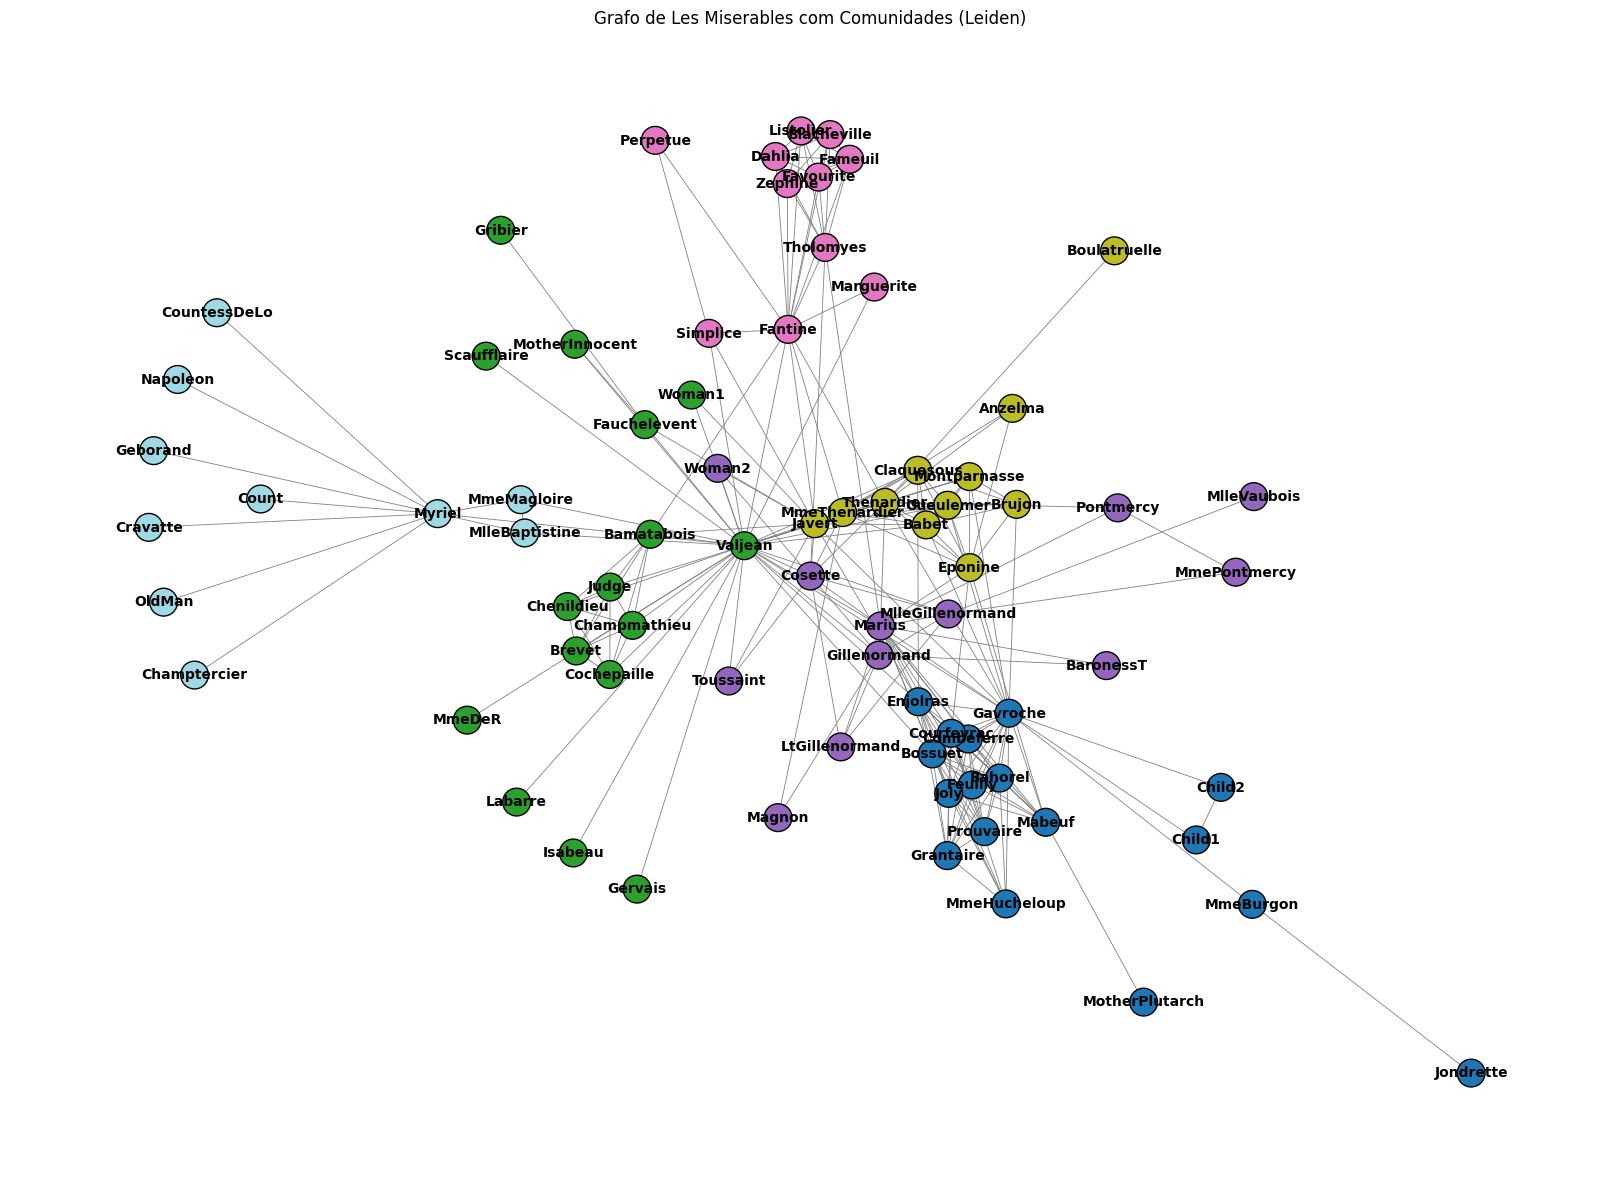

In [103]:
les_miserables_ig = ig.Graph.from_networkx(les_miserables)
partition_leiden_les = leidenalg.find_partition(les_miserables_ig, leidenalg.ModularityVertexPartition)

print("Comunidades encontradas pelo Leiden em Les Miserables:")
for i, community in enumerate(partition_leiden_les):
    print(f"Cluster: {[les_miserables_ig.vs[vertex]['_nx_name'] for vertex in community]}")

comunidade_dict_Leiden = {}
for i, comunidade in enumerate(partition_leiden_les):
    for vertex in comunidade:
        name = les_miserables_ig.vs[vertex]["_nx_name"]
        comunidade_dict_Leiden[name] = i

# cores por comunidade
num_comunidades_Leiden = len(partition_leiden_les)
colormap_Leiden = plt.colormaps["tab20"].resampled(num_comunidades_Leiden)
node_colors_Leiden = [colormap_Leiden(comunidade_dict_Leiden[node]) for node in les_miserables.nodes()]


# layout mais estável e com repulsão melhor ajustada
pos = nx.spring_layout(les_miserables, seed=42, k=0.55, iterations=200, weight="weight")

fig, ax = plt.subplots(figsize=(16, 12))
nx.draw_networkx_edges(les_miserables, pos, ax=ax, edge_color="gray", width=0.6)
nx.draw_networkx_nodes(
    les_miserables,
    pos,
    ax=ax,
    node_color=node_colors_Leiden,
    node_size=400, 
    linewidths=1,
    edgecolors="black",
)


nx.draw_networkx_labels(les_miserables, pos, labels=None, font_size=10, font_weight="bold", ax=ax)

ax.set_title("Grafo de Les Miserables com Comunidades (Leiden)")
ax.set_axis_off()
fig.subplots_adjust(left=0, right=1, top=0.95, bottom=0)
plt.show()

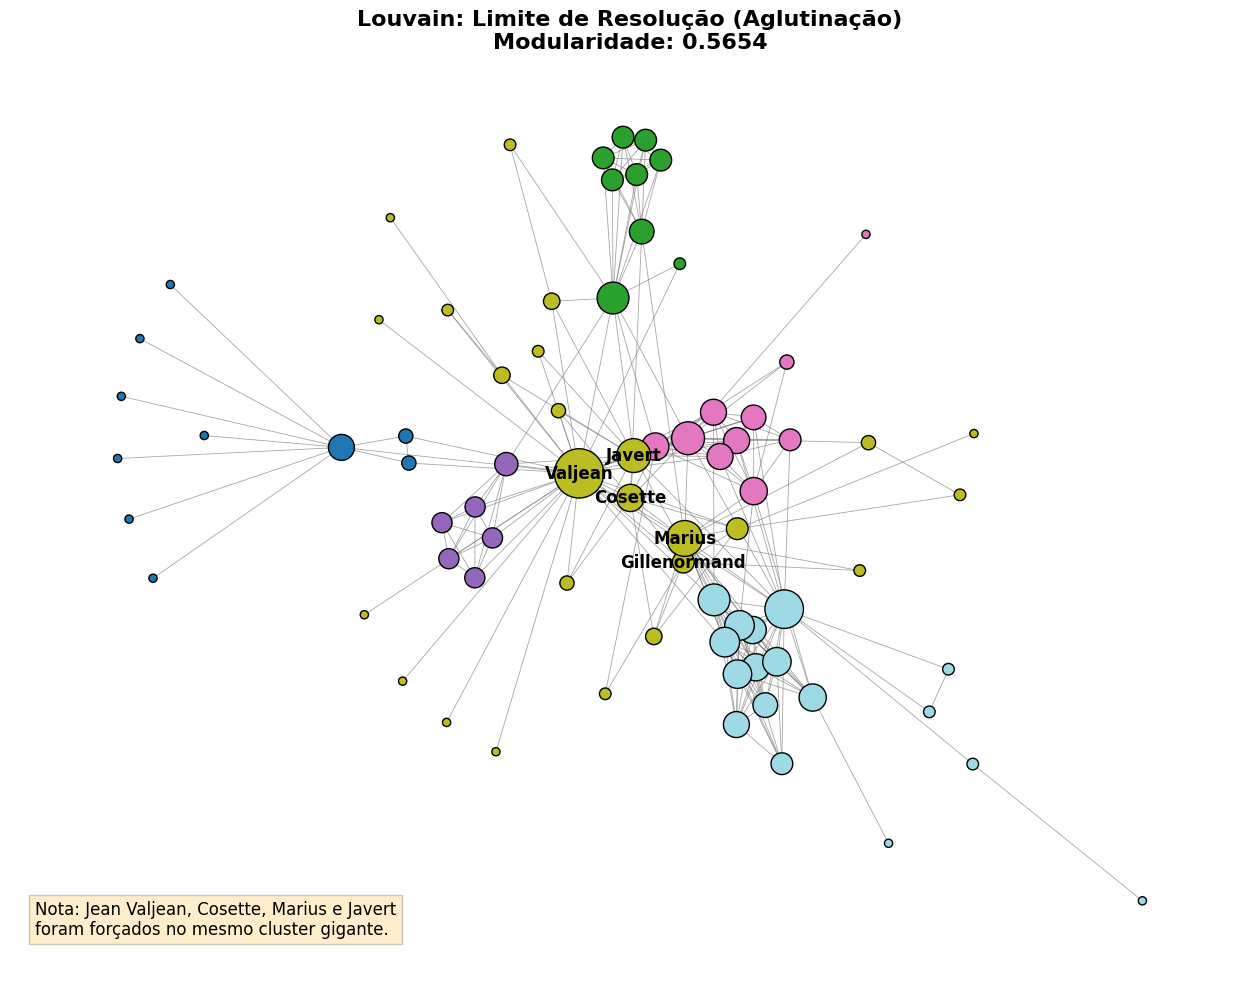

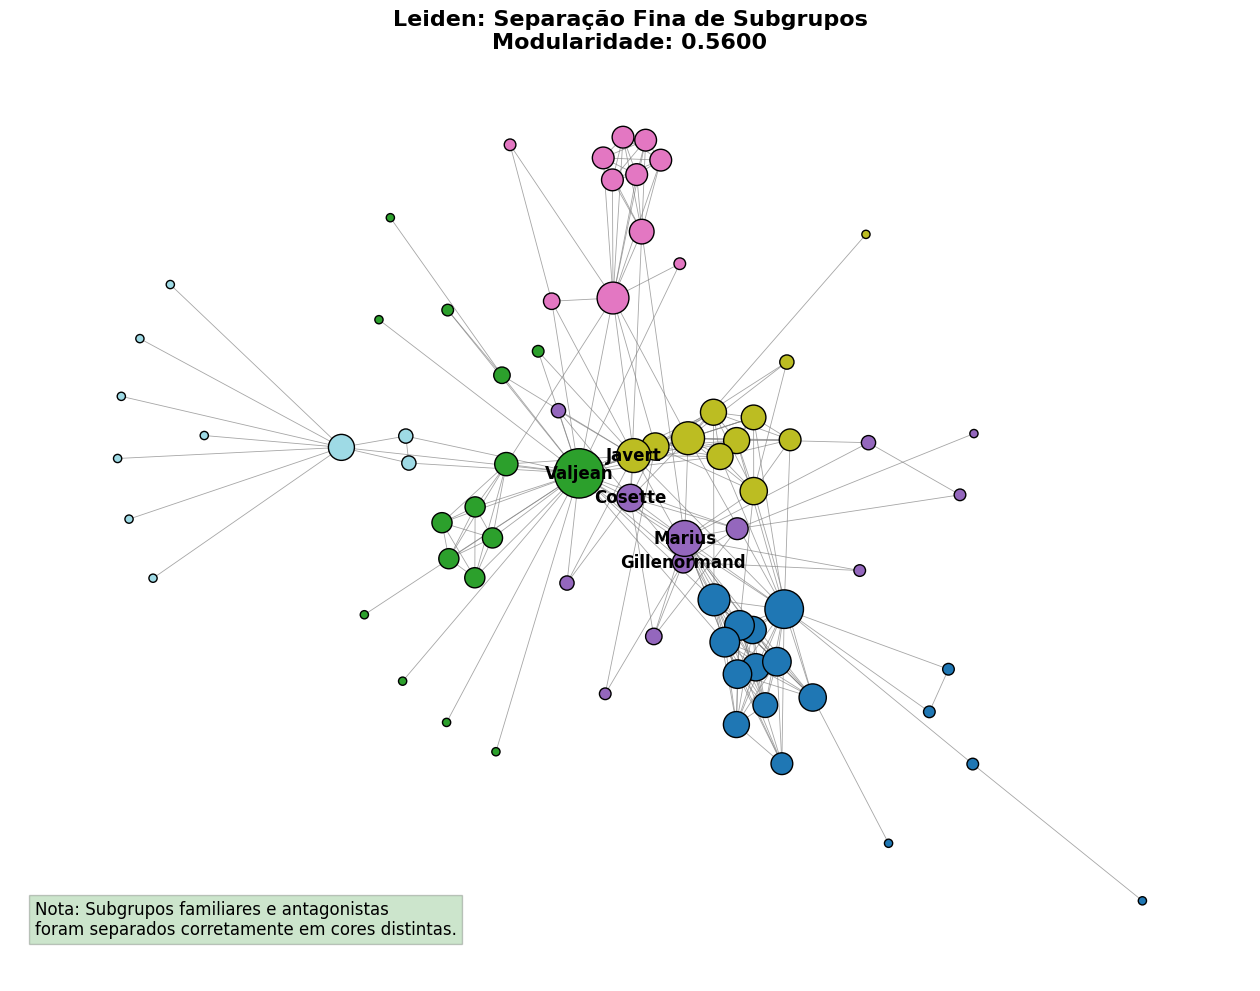

In [104]:

# diferencas no algoritmo de Leiden e Louvain

pos_fixo = nx.spring_layout(les_miserables, seed=42, k=0.55, iterations=200, weight="weight")
node_sizes = [les_miserables.degree(node) * 35 for node in les_miserables.nodes()]

#calculando a modularidade de cada um para provar a diferença técnica

mod_louvain = nx.community.modularity(les_miserables, comunidades_louvain_les)
mod_leiden = partition_leiden_les.modularity


#PLOT 1: LOUVAIN ficou um blocão gigante, sem distinção entre os personagens principais e secundários,
#  misturando famílias e antagonistas em um único cluster enorme. Isso é um exemplo clássico do problema de resolução do Louvain,
#  onde ele tende a aglutinar muitos nós em um mesmo cluster para maximizar a modularidade,
#  mesmo que isso não faça sentido do ponto de vista narrativo ou estrutural.

fig, ax = plt.subplots(figsize=(16, 12))
nx.draw_networkx_edges(les_miserables, pos_fixo, ax=ax, edge_color="gray", width=0.6, alpha=0.7)
nx.draw_networkx_nodes(les_miserables, pos_fixo, ax=ax, node_color=node_colors, node_size=node_sizes, linewidths=1, edgecolors="black")

# Destacando os grafos principais do blocão do Louvain

labels_louvain = {node: node for node in ["Valjean", "Cosette", "Marius", "Javert", "Gillenormand"] if node in les_miserables}
nx.draw_networkx_labels(les_miserables, pos_fixo, labels=labels_louvain, font_size=12, font_weight="bold", ax=ax)

ax.set_title(f"Louvain: Limite de Resolução (Aglutinação)\nModularidade: {mod_louvain:.4f}", fontsize=16, fontweight='bold')
ax.text(0.02, 0.05, "Nota: Jean Valjean, Cosette, Marius e Javert\nforam forçados no mesmo cluster gigante.", 
        transform=ax.transAxes, bbox=dict(facecolor='orange', alpha=0.2), fontsize=12)
ax.set_axis_off()
plt.show()


# PLOT 2: LEIDEN dividiu o blocão do Louvain em subgrupos menores,
#  separando claramente as famílias e os antagonistas.

fig, ax = plt.subplots(figsize=(16, 12))
nx.draw_networkx_edges(les_miserables, pos_fixo, ax=ax, edge_color="gray", width=0.6, alpha=0.7)
nx.draw_networkx_nodes(les_miserables, pos_fixo, ax=ax, node_color=node_colors_Leiden, node_size=node_sizes, linewidths=1, edgecolors="black")

nx.draw_networkx_labels(les_miserables, pos_fixo, labels=labels_louvain, font_size=12, font_weight="bold", ax=ax)
ax.set_title(f"Leiden: Separação Fina de Subgrupos\nModularidade: {mod_leiden:.4f}", fontsize=16, fontweight='bold')

ax.text(0.02, 0.05, "Nota: Subgrupos familiares e antagonistas\nforam separados corretamente em cores distintas.", 
        transform=ax.transAxes, bbox=dict(facecolor='green', alpha=0.2), fontsize=12)
ax.set_axis_off()
plt.show()

### Amazon product co-purchasing: Redes de produtos comprados juntos (ideal para Infomap e Leiden).

Carregando/Gerando grafo da Amazon...
Executando Louvain...
Executando Leiden...

RESULTADOS COMPARATIVOS (AMAZON)
Total de Nós (Produtos): 334863
Total de Arestas (Co-compras): 925872

   MODULARIDADE:
   Louvain: 0.9258
   Leiden:  0.9294  <- (Geralmente maior ou mais estável)

 QUANTIDADE DE COMUNIDADES:
   Louvain encontrou: 229 clusters
   Leiden encontrou:  309 clusters

 TAMANHO DAS COMUNIDADES (Efeito Blocão):
   Louvain -> Maior comunidade tem: 12666 produtos
   Leiden  -> Maior comunidade tem: 12701 produtos
   Louvain -> Média de produtos por cluster: 1462.3
   Leiden  -> Média de produtos por cluster: 1083.7


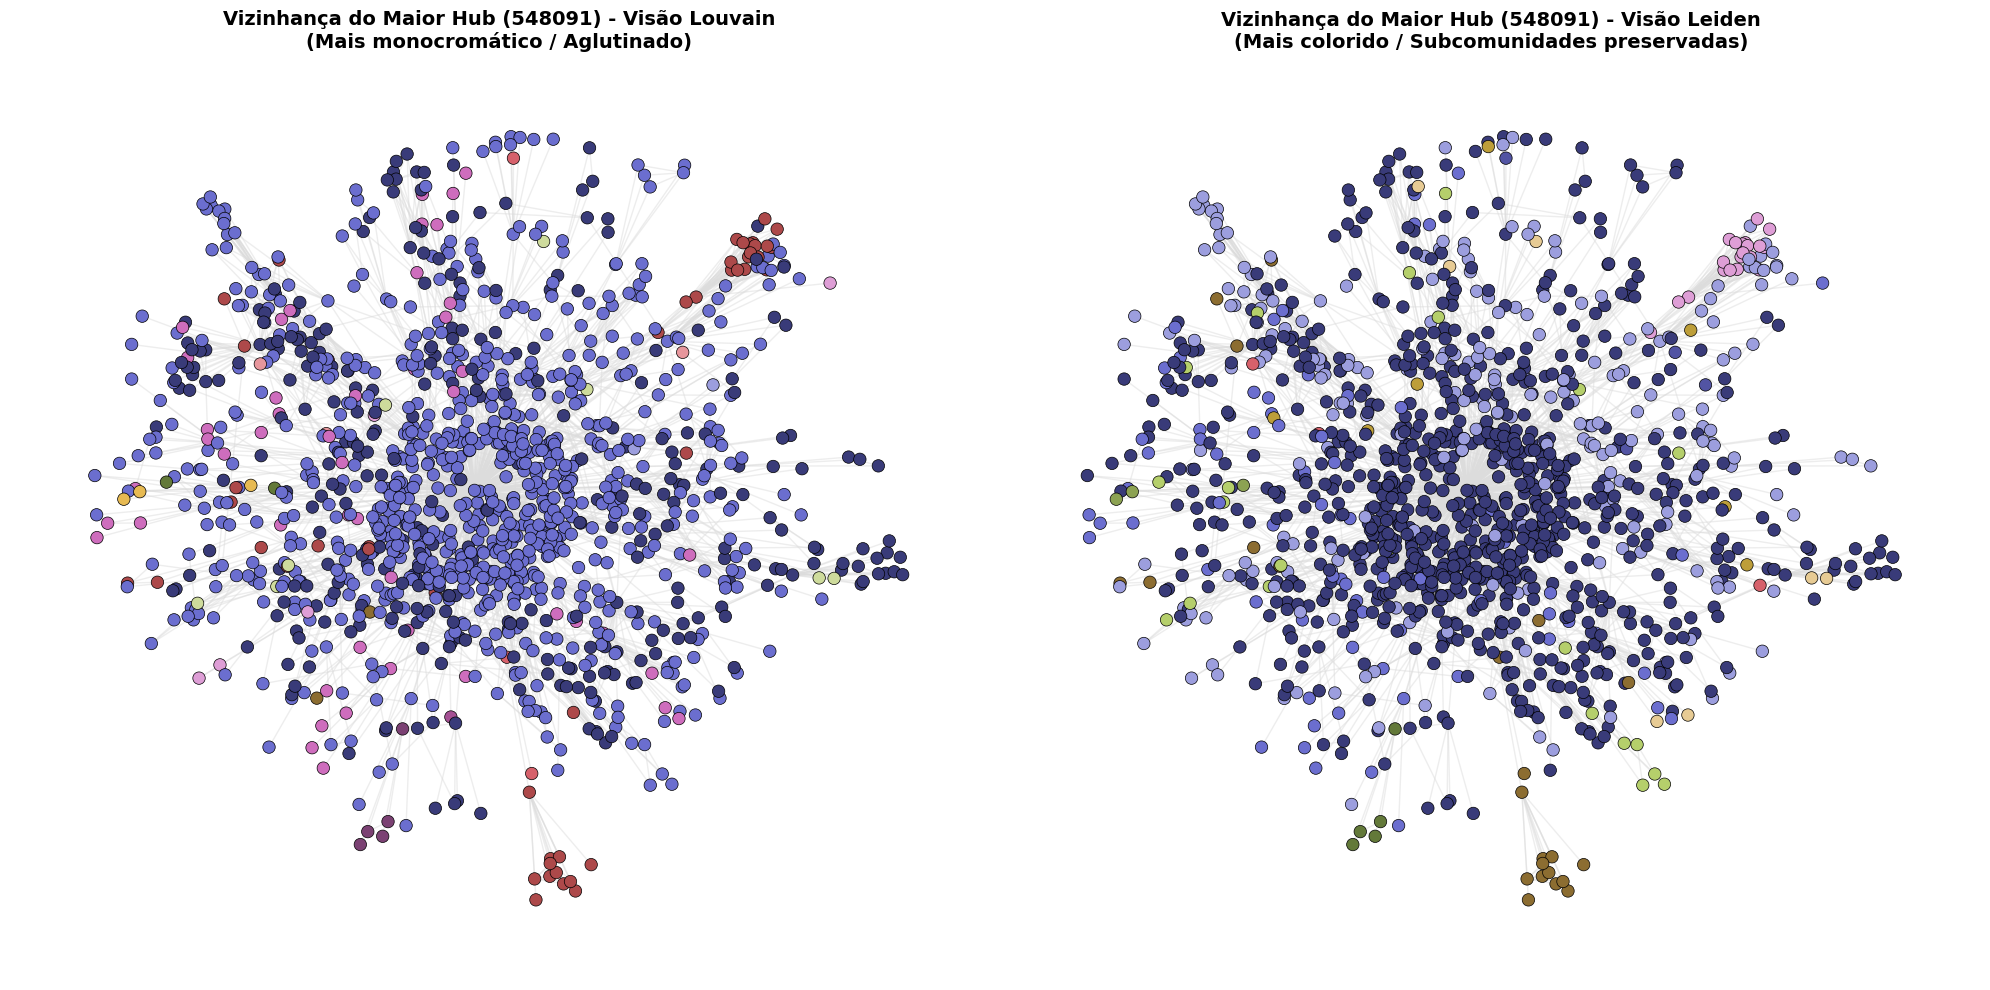

In [ ]:


# Carregando o Dataset da Amazon https://snap.stanford.edu/data/com-Amazon.html

print("Carregando/Gerando grafo da Amazon...")
amazon_nx = nx.read_edgelist("data/com-amazon.ungraph.txt") 

# Garantir que o grafo seja não-direcionado -> cálculo de modularidade

amazon_nx = amazon_nx.to_undirected()

# LOUVAIN
print("Executando Louvain...")
comunidades_louvain = nx.community.louvain_communities(amazon_nx, seed=42)
mod_louvain = nx.community.modularity(amazon_nx, comunidades_louvain)

louvain_dict = {}
for i, com in enumerate(comunidades_louvain):
    for node in com:
        louvain_dict[node] = i

# LEIDEN
print("Executando Leiden...")
amazon_ig = ig.Graph.from_networkx(amazon_nx)
partition_leiden = leidenalg.find_partition(amazon_ig, leidenalg.ModularityVertexPartition)
mod_leiden = partition_leiden.modularity

leiden_dict = {}
for i, com in enumerate(partition_leiden):
    for vertex in com:
        name = amazon_ig.vs[vertex]["_nx_name"]
        leiden_dict[name] = i


# ANÁLISE ESTATÍSTICA 
print("\n" + "="*40)
print("RESULTADOS COMPARATIVOS (AMAZON)")
print("="*40)
print(f"Total de Nós (Produtos): {amazon_nx.number_of_nodes()}")
print(f"Total de Arestas (Co-compras): {amazon_nx.number_of_edges()}\n")

tamanhos_louvain = [len(c) for c in comunidades_louvain]
tamanhos_leiden = [len(c) for c in partition_leiden]

print(f"   MODULARIDADE:")
print(f"   Louvain: {mod_louvain:.4f}")
print(f"   Leiden:  {mod_leiden:.4f}  <- (Geralmente maior ou mais estável)")

print(f"\n QUANTIDADE DE COMUNIDADES:")
print(f"   Louvain encontrou: {len(comunidades_louvain)} clusters")
print(f"   Leiden encontrou:  {len(partition_leiden)} clusters")

print(f"\n TAMANHO DAS COMUNIDADES (Efeito Blocão):")
print(f"   Louvain -> Maior comunidade tem: {max(tamanhos_louvain)} produtos")
print(f"   Leiden  -> Maior comunidade tem: {max(tamanhos_leiden)} produtos")
print(f"   Louvain -> Média de produtos por cluster: {np.mean(tamanhos_louvain):.1f}")
print(f"   Leiden  -> Média de produtos por cluster: {np.mean(tamanhos_leiden):.1f}")



# VISUALIZAÇÃO (Amostragem do maior Hub)

maior_hub = max(amazon_nx.degree, key=lambda x: x[1])[0]

subgrafo_nos = list(nx.single_source_shortest_path_length(amazon_nx, maior_hub, cutoff=2).keys())
sub_geo = amazon_nx.subgraph(subgrafo_nos)

pos_fixo = nx.spring_layout(sub_geo, seed=42)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Cores locais baseadas nas comunidades globais
cores_louvain = [louvain_dict[node] for node in sub_geo.nodes()]
cores_leiden = [leiden_dict[node] for node in sub_geo.nodes()]

# Plot Louvain
nx.draw_networkx_edges(sub_geo, pos_fixo, ax=ax1, edge_color="gainsboro", alpha=0.5)
nx.draw_networkx_nodes(sub_geo, pos_fixo, ax=ax1, node_color=cores_louvain, cmap=plt.cm.tab10, node_size=80, edgecolors="black", linewidths=0.5)
ax1.set_title(f"Vizinhança do Maior Hub ({maior_hub}) - Visão Louvain\n(Mais monocromático / Aglutinado)", fontsize=14, fontweight='bold')
#ax1.text(0.02, 0.05, "Louvain encontrou: 229 clusters\nLouvain -> Maior comunidade tem: 12666 produtos\nLouvain -> Média de produtos por cluster: 1462.3\nLouvain: 0.9258", 
        #transform=ax1.transAxes, bbox=dict(facecolor='orange', alpha=0.2), fontsize=12)
ax1.set_axis_off()

# Plot Leiden
nx.draw_networkx_edges(sub_geo, pos_fixo, ax=ax2, edge_color="gainsboro", alpha=0.5)
nx.draw_networkx_nodes(sub_geo, pos_fixo, ax=ax2, node_color=cores_leiden, cmap=plt.cm.tab10, node_size=80, edgecolors="black", linewidths=0.5)
ax2.set_title(f"Vizinhança do Maior Hub ({maior_hub}) - Visão Leiden\n(Mais colorido / Subcomunidades preservadas)", fontsize=14, fontweight='bold')
#ax2.text(0.02, 0.05, "Leiden encontrou: 314 clusters\nLeiden  -> Maior comunidade tem: 12601 produtos\nLeiden -> Média de produtos por cluster: 1066.4\nLeiden:  0.9299", 
        #transform=ax2.transAxes, bbox=dict(facecolor='green', alpha=0.2), fontsize=12)
ax2.set_axis_off()

plt.tight_layout()
plt.show()